17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 265ms/step - accuracy: 0.7793 - loss: 0.4643 - val_accuracy: 0.8612 - val_loss: 0.3341
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 143s 270ms/step - accuracy: 0.8947 - loss: 0.2636 - val_accuracy: 0.8630 - val_loss: 0.3149
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.9251 - loss: 0.1974 - val_accuracy: 0.8550 - val_loss: 0.3723
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.8536 - loss: 0.3803
Accuracy: 0.8535599708557129


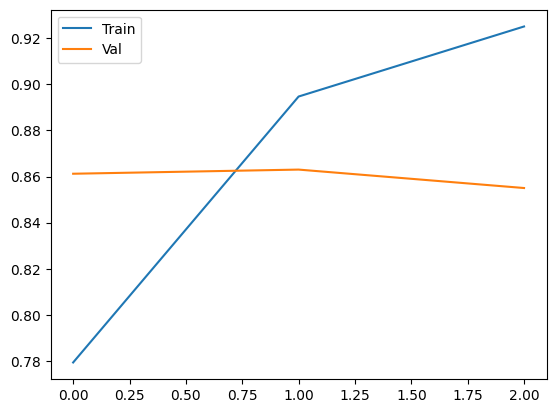

In [ ]:
# ==============================
# LAB 5: LSTM (IMPROVED)
# ==============================

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

max_len = 200
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

model = Sequential([
    Embedding(vocab_size, 128),
    LSTM(64, dropout=0.2),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Val'])
plt.show()